# Introduction
As of 2025-06-12, the volunteers at rangers.urbanrivers have added 59,351 observations.  
These observations are not error-proof, but they are definitely a useful means of creating base-truth casses for image labeling.  

This notebook serves as a means of aggregating those data from the server api in a scaleable manner - to where as observations continue to grow, we can ingest new labels for model improvement


In [1]:
# Data Handling
import pandas as pd

# IO - getting files and images
from pymongo import MongoClient
from kaggle_secrets import UserSecretsClient
import requests
import json
import os
import urllib.parse

# For randomizing which images get downloaded
import random
from tqdm.auto import tqdm

# For model loading and fine tuning
from fastai.vision.all import *
from fastai.vision.widgets import *
import torch

print("==== Loaded Libraries ====")

==== Loaded Libraries ====


# Accessing observations (image labels) from the public api
This version uses pymongo (MongoClient) 

In [2]:
%%time
# Get the stored mongo uri secret
user_secrets = UserSecretsClient()
mongo_uri = user_secrets.get_secret("MONGO_PROD")

# Access the server
client = MongoClient(mongo_uri)
db = client['test']
collection = db['cameratrapmedias']

# Fetch documents with at least one speciesConsensus entry
def fetch_all_obs():
    query = {"speciesConsensus.0": {"$exists": True}}  # at least one item
    projection = {
        "_id": 0,
        "mediaID": 1,
        "publicURL": 1,
        "speciesConsensus": 1
    }
    all_obs = list(collection.find(query, projection))
    print(f"Retrieved {len(all_obs)} documents with speciesConsensus.")
    return all_obs

# Try the fetch operation
try:
    print("===== Starting MongoDB Fetch =====")
    obs_json = fetch_all_obs()
except Exception as e:
    print(f"Error during fetch: {e}")

===== Starting MongoDB Fetch =====
Retrieved 59999 documents with speciesConsensus.
CPU times: user 1.24 s, sys: 208 ms, total: 1.45 s
Wall time: 3.35 s


## Process the returned JSON for the fields we need
We're looking for the `mediaID` (our primary key),  
The `publicURL` that we can use to download the image,  
The `scientificName` that observers have selected and the `observationCount` of times that people have agreed on the species.  
  -  Note this is different than a similar field `count` that represents the number of species in the photo
  -  An `observationCount` increase requires both the species and the `count` to be the same.
  -  For example, a `count` of 1 canis familiaris with a `observationCount` of 1 could also have a `count` of 2 and `observationCount` of 3 if 3 people saw 2 dogs, and 1 person saw 1 dog.
  -  In version 5 we include the count

In [3]:
%%time
# Process the JSON into flat records
def process_obs_json(obs):
    records = []
    for ob in obs:
        media_id = ob.get("mediaID")
        public_url = ob.get("publicURL")
        for species in ob.get("speciesConsensus", []):
            records.append({
                "mediaID": media_id,
                "publicURL": public_url,
                "scientificName": species.get("scientificName"),
                "observationCount": species.get("observationCount"),
                "speciesCount": species.get("count")
            })
    return pd.DataFrame(records)

# Process the returned JSON
try:
    print("===== Starting Data Processing =====")
    df = process_obs_json(obs_json)

    with pd.option_context('display.width', 0, 'display.max_colwidth', None):
        display(df.head())

    print(f"Total records: {len(df)}")
except Exception as e:
    print(f"Error during processing: {e}")

===== Starting Data Processing =====


,mediaID,publicURL,scientificName,observationCount,speciesCount
0,c112813a5f3b9cec26f95fad982b8d09,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-01-30_prologis_02/DCIM/100MEDIA/SYFW0001.JPG,None,1,1
1,0647380f2d59692f5b2b642312844e9f,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-01-30_prologis_02/DCIM/100MEDIA/SYFW0002.JPG,None,1,1
2,0db73c6c1efb4968c04a47e418ebeefb,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-01-30_prologis_02/DCIM/100MEDIA/SYFW0004.JPG,None,1,1
3,31fc53de29056b4dd8bc7b1804617f00,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-01-30_prologis_02/DCIM/100MEDIA/SYFW0006.JPG,None,1,1
4,14664d764836c5fd9a38284dc6103527,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-01-30_prologis_02/DCIM/100MEDIA/SYFW0008.JPG,None,1,1


Total records: 67691
CPU times: user 142 ms, sys: 14.2 ms, total: 157 ms
Wall time: 164 ms


## Save data as we go along for referencing later as needed
We're going to 'checkpoint' a few files while filtering because we might go back or try different types of classification or detection later


In [4]:
# Save the processed data as is
os.makedirs('/kaggle/working/data', exist_ok=True)
df.to_csv('/kaggle/working/data/initial_processed_data.csv', index=False)
df = pd.read_csv("/kaggle/working/data/initial_processed_data.csv")
print("\n==== Saved checkpoint 1 ====\n")


==== Saved checkpoint 1 ====



# Data Cleaning and Filtering
The raw data from the observations could have a few issues:  
Duplication - if there are bugs in the observation recording process
False positives - if people classify the wrong species in an image, or accidentally classify multiple when there is only one
False negatives - from time to time, people could be classifying long groups of blanks, and then accidentally skip an image with an animal

In [5]:
# Solve the potential duplicates for every image and observation - just want a validated list
df2 = df.drop_duplicates().reset_index(drop=True)
with pd.option_context('display.width', 0, 'display.max_colwidth', None):
    display(df2.head())

print(f'Total rows: {len(df2)}\n')
print(df2['scientificName'].value_counts())

,mediaID,publicURL,scientificName,observationCount,speciesCount
0,c112813a5f3b9cec26f95fad982b8d09,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-01-30_prologis_02/DCIM/100MEDIA/SYFW0001.JPG,NaN,1,1
1,0647380f2d59692f5b2b642312844e9f,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-01-30_prologis_02/DCIM/100MEDIA/SYFW0002.JPG,NaN,1,1
2,0db73c6c1efb4968c04a47e418ebeefb,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-01-30_prologis_02/DCIM/100MEDIA/SYFW0004.JPG,NaN,1,1
3,31fc53de29056b4dd8bc7b1804617f00,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-01-30_prologis_02/DCIM/100MEDIA/SYFW0006.JPG,NaN,1,1
4,14664d764836c5fd9a38284dc6103527,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-01-30_prologis_02/DCIM/100MEDIA/SYFW0008.JPG,NaN,1,1


Total rows: 67077

scientificName
Branta canadensis            4362
Anas platyrhynchos           3422
Trachemys scripta elegans    2251
Rattus norvegicus            1406
Apalone spinifera            1314
                             ... 
Nannopterum                     1
Ardea                           1
Ictaluridae                     1
Siluriformes                    1
Actinopterygii                  1
Name: count, Length: 121, dtype: int64


## Counts vs ObsCounts
In version 5 of this notebook we added speciesCount - When deduplicating, now if there are votes for 1x and 2x of a species, there are potentially new rows.  
We'll maintain a minimum vote requirement of 3 - this should reduce times where only 1 or 2 people have voted incorrectly.

In [6]:
# Filter to species with at least 3 votes
df3 = df2[(df2['observationCount'] >= 3) ]
df3.loc[:, 'scientificName'] = df3['scientificName'].fillna("blank")
df3 = df3.sort_values(by='observationCount', ascending=False).reset_index(drop=True)
with pd.option_context('display.width', 0, 'display.max_colwidth', None):
    display(df3.head())

print(f'Total rows: {len(df3)}\n')
print(df3['scientificName'].value_counts())

,mediaID,publicURL,scientificName,observationCount,speciesCount
0,ff2c1b7718fd23de7d4f13086aa94fa3,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-03-23_WildMileNorth/DCIM/100MEDIA/SYFW2126.JPG,blank,10,1
1,8a95a3db6dac5ec39a1d7d4d3866b694,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-03_UR011/DCIM/100MEDIA/SYFW2955.JPG,Castor canadensis,9,1
2,2b38de3083349c8aafce8b6d66bb7aeb,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-03_UR011/DCIM/100MEDIA/SYFW2954.JPG,Castor canadensis,9,1
3,f4e25c036a53d2d204de57c5fd3ce782,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-03_UR011/DCIM/100MEDIA/SYFW2953.JPG,Castor canadensis,9,1
4,eae1c8e369ca98c1fde6961ce1389f68,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-03-23_WildMileNorth/DCIM/100MEDIA/SYFW2128.JPG,blank,9,1


Total rows: 5605

scientificName
blank                        3903
Branta canadensis             627
Actitis macularius            232
Anas platyrhynchos            227
Trachemys scripta elegans     150
Canis familiaris              144
Castor canadensis              70
Apalone spinifera              49
Ardea herodias                 45
Turdus migratorius             29
Sylvilagus floridanus          29
Nycticorax nycticorax          20
Ondatra zibethicus             17
Rattus norvegicus              17
Procyon lotor                  16
Passer domesticus              12
Aves                            4
Sturnus vulgaris                3
Spizelloides arborea            3
Larus delawarensis              2
Canis latrans                   1
Butorides virescens             1
Junco hyemalis                  1
Fulica americana                1
Quiscalus quiscula              1
Parkesia noveboracensis         1
Name: count, dtype: int64


You can tell now that our value_counts report is showing the full list of species because some more rare species haven't been confirmed by at least 3 people.  

## Identifying multiple classification images vs single classification
Animals share spaces.  
As long as there isn't animosity, it's very possible that some images have more than one species -  
For the purpose of model type, we need to delineate what we're fine-tuning to, so it's important to group and understand the nature of each image from the observations.

### Dropping speciesCount while grouping
The group by below directly references mediaID and publicURL - this effectively collapses the potential for images with 1 count of a species together with multiple counts.  
Another options here would be to include the speciesCount in the group by if we wanted to start classifying the number in addition to the type in images (we don't for now).  
ex:  
`df3_grouped = df3.groupby(['mediaID', 'publicURL', 'speciesCount'])['scientificName'] \ ...`

In [7]:
# This might be a multiple classification problem - let's see if things change when we group by and list the scientific names
df3_grouped = df3.groupby(['mediaID', 'publicURL'])['scientificName'] \
    .agg(lambda x: ';'.join(sorted(set(x)))) \
    .reset_index()

# To keep classes where only blank and yet not ones containing blank
def is_only_blank(label_str):
    return label_str.strip() == "blank"

# Filter: keep rows where "blank" is not in the list OR is the only label
# This is because sometimes people are categorizing multiple blanks in a row and do not see the animal while zoned out.
df3_grouped = df3_grouped[
    ~df3_grouped['scientificName'].str.contains(';blank') |
    df3_grouped['scientificName'].apply(is_only_blank)
]

# Show the results
with pd.option_context('display.width', 0, 'display.max_colwidth', None):
    display(df3_grouped.head())
    
print(f'Total rows: {len(df3_grouped)}\n')
print(df3_grouped['scientificName'].value_counts())

,mediaID,publicURL,scientificName
0,0012b4e8945c8927c20c58434de3934c,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-05-12_Prologis/DCIM/101SYCAM/SYEW4294.JPG,blank
1,0017307382475a160ccf074bf437115b,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/100MEDIA/SYFW0781.JPG,Anas platyrhynchos;Branta canadensis
2,00267b4d15190254cb2b36c7dbcd285a,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-05-16_WM_Boardwalk_D/DCIM/100DSCIM/PICT0764.JPG,blank
3,002ef4135a20bed6c3643f9f0bb884a2,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-09-14_UR013/DCIM/100MEDIA/SYFW0316.JPG,blank
4,002fe9a5dc3a1bf6b14298838bae6982,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-05-12_Prologis/DCIM/101SYCAM/SYEW0819.JPG,Branta canadensis


Total rows: 5131

scientificName
blank                                                             3743
Branta canadensis                                                  557
Actitis macularius                                                 168
Anas platyrhynchos                                                 166
Trachemys scripta elegans                                           56
Actitis macularius;Trachemys scripta elegans                        53
Castor canadensis                                                   48
Anas platyrhynchos;Branta canadensis                                40
Ardea herodias                                                      39
Turdus migratorius                                                  29
Sylvilagus floridanus                                               28
Canis familiaris                                                    26
Apalone spinifera;Trachemys scripta elegans                         21
Nycticorax nycticorax                       

In [8]:
# Save the filtered df as a starting point for image requests and multiclassification future decisions
df3_grouped.to_csv("/kaggle/working/data/all_labeled_species_urls.csv", index=False)
print("\n==== Saved checkpoint 2 ====\n")


==== Saved checkpoint 2 ====



### As of 2025-06-13 there are 1379 rows for the 36 classifications

There are a few that are classified as multiple species - for now, let's focus on those that are just single labeled.

In [9]:
# We're going to focus on single species labeled images and blanks for an attempt at training a simple classification model - a scientific name always has at least one space - so we'll filter one last time.
df4 = df3_grouped[(~df3_grouped["scientificName"].str.contains(";")) & (df3_grouped["scientificName"].str.contains(" ")) | (df3_grouped["scientificName"] == 'blank')]

# Show the results
with pd.option_context('display.width', 0, 'display.max_colwidth', None):
    display(df4.head())
    
print(f'Total rows: {len(df4)}\n')
print(df4['scientificName'].value_counts())

,mediaID,publicURL,scientificName
0,0012b4e8945c8927c20c58434de3934c,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-05-12_Prologis/DCIM/101SYCAM/SYEW4294.JPG,blank
2,00267b4d15190254cb2b36c7dbcd285a,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-05-16_WM_Boardwalk_D/DCIM/100DSCIM/PICT0764.JPG,blank
3,002ef4135a20bed6c3643f9f0bb884a2,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-09-14_UR013/DCIM/100MEDIA/SYFW0316.JPG,blank
4,002fe9a5dc3a1bf6b14298838bae6982,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-05-12_Prologis/DCIM/101SYCAM/SYEW0819.JPG,Branta canadensis
5,0032759e5c6eb2df7b23b58e9c68f59c,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-03_UR011/DCIM/100MEDIA/SYFW3154.JPG,Actitis macularius


Total rows: 4960

scientificName
blank                        3743
Branta canadensis             557
Actitis macularius            168
Anas platyrhynchos            166
Trachemys scripta elegans      56
Castor canadensis              48
Ardea herodias                 39
Turdus migratorius             29
Sylvilagus floridanus          28
Canis familiaris               26
Nycticorax nycticorax          20
Rattus norvegicus              17
Procyon lotor                  15
Ondatra zibethicus             15
Passer domesticus              11
Apalone spinifera               9
Spizelloides arborea            3
Sturnus vulgaris                3
Canis latrans                   1
Larus delawarensis              1
Fulica americana                1
Quiscalus quiscula              1
Parkesia noveboracensis         1
Junco hyemalis                  1
Butorides virescens             1
Name: count, dtype: int64


## Single species type in image subset - 
### As of 2025-06-20 there are 4960 rows for 25 classified species
There are some more rare species than others.  

Branta canadensis - the canadian goose - there are 55 images exist of that classification today, where..  
Castor canadensis - the beaver - only has 48 and ..  
Nycticorax nycticorax - the Night Heron - only has 20 (but we do have a lot of them in photos)  

Part of this is because people don't recognize some speces - lumping them into a higher taxonomic class, like 'aves'.  
For the purpose of having a good number of images for training we need to set a minimum threshold.  

For right now, we're going to use 26, but realistic production models might need more like 200.  
The decision to allow at least 26 is to have more classes for fine-tuning and testing:  
25 for training with a 20% validation (5 of 25) and 1 for testing later.

## Set a minimum number of observations so our model has some chance at learning

In [10]:
# Adjust as the project progresses:
n_obs_minimum = 26

In [11]:
# Filter current df to where the minimum is met
species_counts = df4['scientificName'].value_counts()
species_to_keep = species_counts[species_counts >= n_obs_minimum].index

df5 = df4[df4['scientificName'].isin(species_to_keep)]

# Show the results
with pd.option_context('display.width', 0, 'display.max_colwidth', None):
    display(df5.head())
    
print(f'Total rows: {len(df5)}\n')
print(df5['scientificName'].value_counts())

,mediaID,publicURL,scientificName
0,0012b4e8945c8927c20c58434de3934c,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-05-12_Prologis/DCIM/101SYCAM/SYEW4294.JPG,blank
2,00267b4d15190254cb2b36c7dbcd285a,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-05-16_WM_Boardwalk_D/DCIM/100DSCIM/PICT0764.JPG,blank
3,002ef4135a20bed6c3643f9f0bb884a2,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-09-14_UR013/DCIM/100MEDIA/SYFW0316.JPG,blank
4,002fe9a5dc3a1bf6b14298838bae6982,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-05-12_Prologis/DCIM/101SYCAM/SYEW0819.JPG,Branta canadensis
5,0032759e5c6eb2df7b23b58e9c68f59c,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-03_UR011/DCIM/100MEDIA/SYFW3154.JPG,Actitis macularius


Total rows: 4860

scientificName
blank                        3743
Branta canadensis             557
Actitis macularius            168
Anas platyrhynchos            166
Trachemys scripta elegans      56
Castor canadensis              48
Ardea herodias                 39
Turdus migratorius             29
Sylvilagus floridanus          28
Canis familiaris               26
Name: count, dtype: int64


### We're left with 4860 rows for 10 classifications 
includes dogs and blanks

In [12]:
# save the single species images with at least n observations as a data checkpoint
df5.to_csv(f'/kaggle/working/data/species_over{n_obs_minimum}.csv', index=False)
print("\n==== Saved checkpoint 3 ====\n")


==== Saved checkpoint 3 ====



# Downloading Images that meet the criteria
Passing our filtered df to the s3 bucket to request images in grouped train or test splits

In [13]:
# Select the df cleaning state we want to use
df = df5

# Create the directories
base_dir = '/kaggle/working/images'
test_dir = '/kaggle/working/_tests'
os.makedirs(test_dir, exist_ok=True)

# Shuffle the whole DataFrame first to ensure randomness
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
grouped = list(df_shuffled.groupby('scientificName'))

In [14]:
# Show the structure of the grouped list for understanding
print("speciesName: ", grouped[0][0])
print("dataframe: ")
grouped[0][1].head()

speciesName:  Actitis macularius
dataframe: 


,mediaID,publicURL,scientificName
1,b1729741f982e7c0fde0c4424401b622,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/101MEDIA/SYFW0551.JPG,Actitis macularius
54,01329be67211abc650eba30abe337bdf,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-03_UR011/DCIM/100MEDIA/SYFW3211.JPG,Actitis macularius
75,9c0fb98c67472b4f7c5a1d832e54e1ca,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-27_UR011/DCIM/100MEDIA/SYFW5527.JPG,Actitis macularius
157,63ab8efc82d9ebf48a5a80b0b471e9cb,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-06-03_UR011/DCIM/100MEDIA/SYFW3071.JPG,Actitis macularius
228,68184f2d01bacdf85d094b9fdd938a7d,https://urbanriverrangers.s3.amazonaws.com/images/2024/2024-05-25_WM_Boardwalk_G/DCIM/100MEDIA/SYFW0064.JPG,Actitis macularius


## Grouped is a list where each index species has a dataframe  so key, value is scientific_name, df of images

/kaggle/working/images/Actitis_macularius/b1729741f982e7c0fde0c4424401b622.jpg


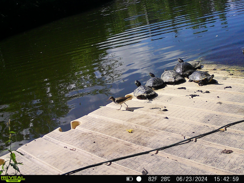

In [15]:
# fast ai version of image downloading
from fastdownload import download_url

ims = grouped[0][1]['publicURL'].tolist()
imn = grouped[0][1]['mediaID'].tolist()

len(ims)

dest = os.path.join(base_dir, grouped[0][0].replace(' ','_'), f'{imn[0]}.jpg')
print(dest)

download_url(ims[0], dest)

im = Image.open(dest)
im.to_thumb(244,244)

Clearly some issues with single species including multiple species - we've seen this before and it will require some cleaning.

In [16]:
# For cleanup while testing
!rm /kaggle/working/images/* -rf

In [17]:
%%time
# fast ai version of all images downloading - drops the mediaID from the pipeline which might be ok
for species, group in grouped:
    group = group.dropna(subset=['publicURL'])
    if len(group) < n_obs_minimum:
        continue

    selected = group.sample(n=n_obs_minimum, random_state=42).reset_index(drop=True)
    n_split = n_obs_minimum - 1
    train_samples = selected.iloc[:n_split]
    test_sample = selected.iloc[n_split]

    train_urls = train_samples['publicURL'].tolist()
    test_url = test_sample['publicURL']
    
    
    species_folder = species.replace(' ', '_')
    species_dir = os.path.join(base_dir, species_folder)
    
    download_images(species_dir, urls=train_urls)
    print(species_dir)
    
    # Download test image
    test_image_path = os.path.join(test_dir, f'{species_folder}.JPG')
    download_url(test_url, test_image_path)

print("==== Downloaded Images ====")
    

/kaggle/working/images/Actitis_macularius


/kaggle/working/images/Anas_platyrhynchos


/kaggle/working/images/Ardea_herodias


/kaggle/working/images/Branta_canadensis


/kaggle/working/images/Canis_familiaris


...

/kaggle/working/images/Sylvilagus_floridanus


/kaggle/working/images/Trachemys_scripta_elegans


/kaggle/working/images/Turdus_migratorius


/kaggle/working/images/blank


==== Downloaded Images ====
CPU times: user 3.84 s, sys: 2.82 s, total: 6.66 s
Wall time: 35.1 s


In [18]:
# validate images
fns = get_image_files(base_dir)
failed = verify_images(fns)
print(failed)
failed.map(Path.unlink);

[]


# For each image downloaded we are going to interact with fastai
Dataloaders (dls) are tensors that fastai simplifies for use in model fine-tuning.  
The library loads only what's needed (even though we passed * at the top) and has some built in common features.  

We're planning on using resnet18 - so we want to resize to 224x224 - and want to use aug_transforms() to get some visual variation in images from cameratraps.  
This means that at each pass of the dls to the fine tuning system the model will see slightly different images so it learns how to detect with some variation.

==== Loading images into tensors ====

CPU times: user 14.1 s, sys: 12.3 s, total: 26.4 s
Wall time: 25.8 s


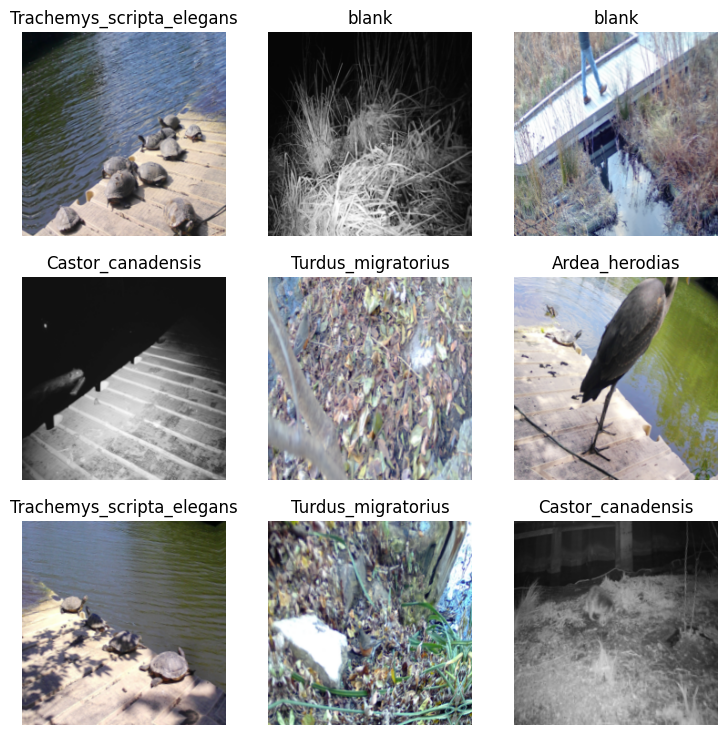

In [19]:
%%time
print('==== Loading images into tensors ====\n')
from sklearn.model_selection import train_test_split

path = Path('/kaggle/working/images')

# Stratified split to balance classes in train/valid sets
def stratified_splitter(items):
    labels = [parent_label(i) for i in items]
    train_idx, valid_idx = train_test_split(
        range(len(items)),
        test_size=0.2,
        stratify=labels,
        random_state=42
    )
    return train_idx, valid_idx

# Custom image trimming class
class CropTopBottom(Transform):
    def __init__(self, top_pct=0.1, bottom_pct=0.1):
        self.top_pct = top_pct
        self.bottom_pct = bottom_pct

    def encodes(self, img: PILImage):
        w, h = img.size
        top = int(h * self.top_pct)
        bottom = int(h * (1 - self.bottom_pct))
        return img.crop((0, top, w, bottom))

# DataBlock with custom splitter - removed batch transforms because the center zoom was cropping animals
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=stratified_splitter,
    item_tfms=[CropTopBottom(top_pct=0.1, bottom_pct=0.1), Resize(224, method='squish')],
    batch_tfms=aug_transforms()
)

# Build DataLoaders
dls = dblock.dataloaders(path)

# Show sample batch
dls.show_batch(max_n=9)

Now when resizing we aren't cutting off animals not centered and aren't introducing new zero padded areas.

# Fine tuning pre-trained models to our classifications
Initially we downloaded the resnet 18 model and fine tuned with 5 epochs to our dataset.  
Images , tests, and data are organized in folders and loaded into dls as appropriate.  

# Seeing what models are best
https://www.kaggle.com/code/morescope/which-image-models-are-best/

In [20]:
import timm
timm.list_models('convnext*')

['convnext_atto',
 'convnext_atto_ols',
 'convnext_atto_rms',
 'convnext_base',
 'convnext_femto',
 'convnext_femto_ols',
 'convnext_large',
 'convnext_large_mlp',
 'convnext_nano',
 'convnext_nano_ols',
 'convnext_pico',
 'convnext_pico_ols',
 'convnext_small',
 'convnext_tiny',
 'convnext_tiny_hnf',
 'convnext_xlarge',
 'convnext_xxlarge',
 'convnext_zepto_rms',
 'convnext_zepto_rms_ols',
 'convnextv2_atto',
 'convnextv2_base',
 'convnextv2_femto',
 'convnextv2_huge',
 'convnextv2_large',
 'convnextv2_nano',
 'convnextv2_pico',
 'convnextv2_small',
 'convnextv2_tiny']

In [21]:
%%time
learn = vision_learner(dls, 'convnext_tiny', metrics=error_rate)

if torch.cuda.is_available():
    learn.model = learn.model.cuda()
    print("Using:", next(learn.model.parameters()).device)  # should print 'cuda:0'
else:
    learn.model = learn.model.cpu()
    print("Using CPU")

# For this version we're trying 10 epochs
learn.fine_tune(5)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Using CPU


epoch,train_loss,valid_loss,error_rate,time
0,3.531904,2.317740,0.840000,01:44


epoch,train_loss,valid_loss,error_rate,time
0,1.687067,1.630390,0.560000,02:09
1,1.307098,0.898087,0.260000,01:55
2,1.018691,0.517217,0.080000,02:03
3,0.810428,0.384409,0.100000,01:54
4,0.668032,0.340267,0.100000,01:53


CPU times: user 12min 41s, sys: 3min 39s, total: 16min 20s
Wall time: 11min 42s


We went from 78 to 92% accuracy switching from resnet18 to convnext_tiny

## Confusion Matrix

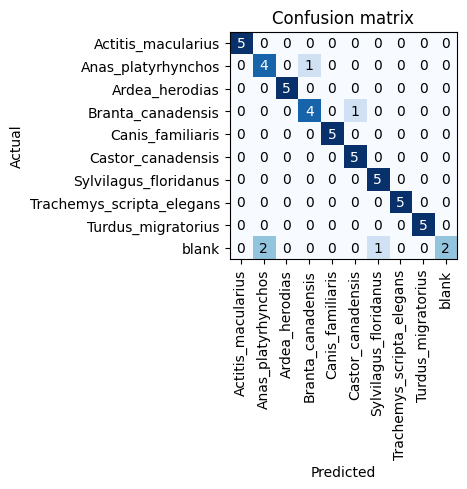

In [22]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

Considerably better error rates on our dog, duck, and sandpiper categories
But now blanks are not being labeled well.  

This is ok - we're alright with a high false positive rate (meaning it's actually blank, but there might be an animal worth looking for?)

## Testing a single image prediction
Here we'll look at our test for a beaver and see if the model can predict it correctly.

<Axes: title={'center': 'Probably: Castor_canadensis (0.96)'}>

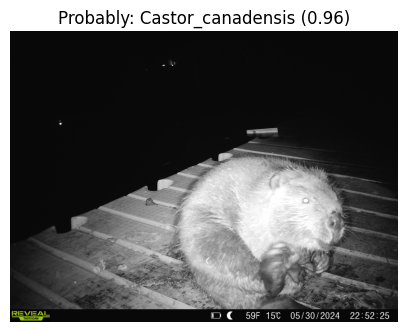

In [23]:
image_path = '/kaggle/working/_tests/Castor_canadensis.JPG'
pred, pred_idx, probs = learn.predict(PILImage.create(image_path))


PILImage.create(image_path).show(title=f"Probably: {pred} ({probs[pred_idx]:.2f})")

## Tabular predictions for all images in the folder

In [24]:
# Predicting in a table for each image
test_path = Path("/kaggle/working/_tests")
test_files = get_image_files(test_path)

results = []
for f in test_files:
    pred_class, pred_idx, pred_probs = learn.predict(f)
    results.append({
        'file': f.name,
        'pred_class': str(pred_class),
        'probability': float(pred_probs[pred_idx]),
        'top3': [
            (learn.dls.vocab[i], format(float(pred_probs[i]), ".4f"))
            for i in pred_probs.argsort(descending=True)[:3]
        ]
    })

results_df = pd.DataFrame(results)
display(results_df)

,file,pred_class,probability,top3
0,Ardea_herodias.JPG,Ardea_herodias,0.986673,"[(Ardea_herodias, 0.9867), (Actitis_macularius, 0.0072), (Canis_familiaris, 0.0036)]"
1,Trachemys_scripta_elegans.JPG,Trachemys_scripta_elegans,0.987713,"[(Trachemys_scripta_elegans, 0.9877), (Actitis_macularius, 0.0039), (blank, 0.0024)]"
2,blank.JPG,Canis_familiaris,0.724764,"[(Canis_familiaris, 0.7248), (blank, 0.0794), (Actitis_macularius, 0.0614)]"
3,Canis_familiaris.JPG,Canis_familiaris,0.966618,"[(Canis_familiaris, 0.9666), (Actitis_macularius, 0.0130), (Turdus_migratorius, 0.0066)]"
4,Turdus_migratorius.JPG,Turdus_migratorius,0.990745,"[(Turdus_migratorius, 0.9907), (blank, 0.0016), (Trachemys_scripta_elegans, 0.0015)]"
5,Sylvilagus_floridanus.JPG,Sylvilagus_floridanus,0.992523,"[(Sylvilagus_floridanus, 0.9925), (Turdus_migratorius, 0.0031), (Ardea_herodias, 0.0013)]"
6,Anas_platyrhynchos.JPG,Anas_platyrhynchos,0.914911,"[(Anas_platyrhynchos, 0.9149), (Actitis_macularius, 0.0401), (Branta_canadensis, 0.0370)]"
7,Castor_canadensis.JPG,Castor_canadensis,0.960889,"[(Castor_canadensis, 0.9609), (blank, 0.0089), (Ardea_herodias, 0.0067)]"
8,Branta_canadensis.JPG,Branta_canadensis,0.296862,"[(Branta_canadensis, 0.2969), (Canis_familiaris, 0.1665), (blank, 0.1055)]"
9,Actitis_macularius.JPG,Actitis_macularius,0.996237,"[(Actitis_macularius, 0.9962), (Anas_platyrhynchos, 0.0023), (Trachemys_scripta_elegans, 0.0009)]"


## A pretty prediction plot for 9 of the test images

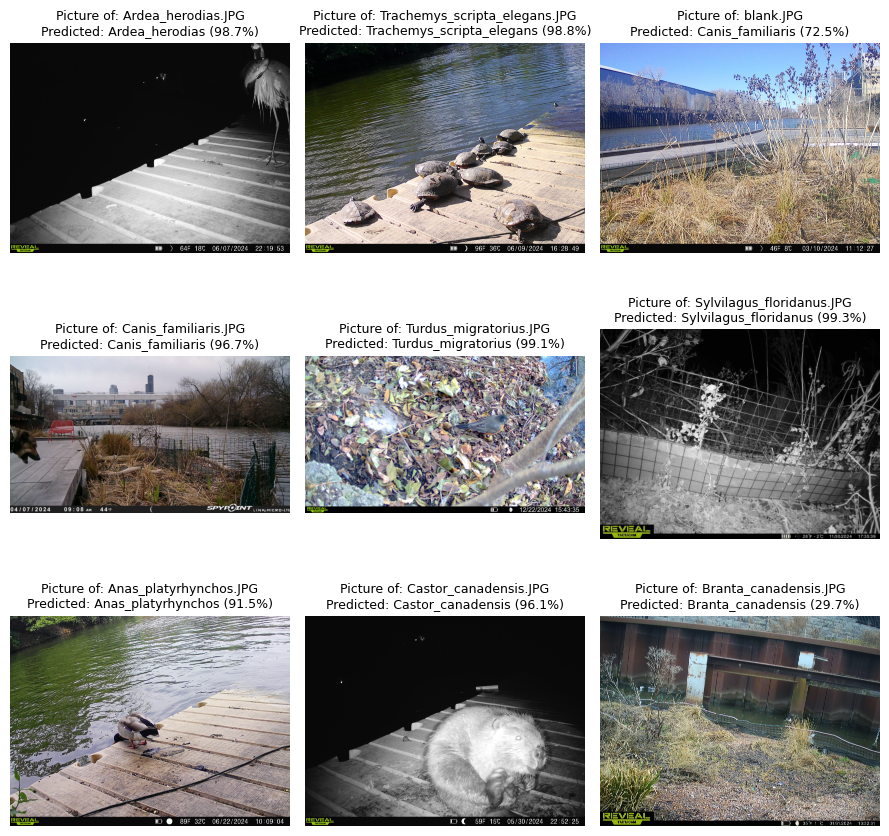

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

for ax, img_file in zip(axes, test_files):
    img = PILImage.create(img_file)
    pred_class, pred_idx, pred_probs = learn.predict(img)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Picture of: {img_file.name}\nPredicted: {pred_class} ({pred_probs[pred_idx]:.1%})", fontsize=9)

# Hide unused subplots if fewer than 9 images
for ax in axes[len(test_files):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Exporting the fine tuned model

In [26]:
# export the model for futher use
learn.export('/kaggle/working/2025-06-20-convnet_tinyx25p-v11.pkl')